In [1]:
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
from moc.models.mixture.mixture_model import MixtureLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
from moc.metrics.metrics_computer import compute_coverage_indicator, compute_log_region_size
from moc.conformal.conformalizers import L_CP, HDR_H
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
# import wandb

In [2]:
config = get_config()
config.device = 'cpu'
M = 100
alphas = torch.linspace(0, 1, M, device=config.device)

In [3]:
def ensemble_PIT(samples, y):
        pca = PCA(n_components=len(y[0])) #keeping all components, 4 in this case
        pca.fit(samples.reshape(-1,len(y[0])))
        vectors = pca.components_ #4 by 4
        pits = []
        for i in range(len(vectors)):
            u = torch.as_tensor(vectors[i], dtype=samples.dtype, device=samples.device)
            sample_proj = torch.matmul(samples, u) # 256,100,1
            y_proj = torch.matmul(y, u) #256,1
            sample_sorted = torch.sort(sample_proj)[0] #256,100 sort across the columns
            n = len(samples[0]) #100
            cdf_values = torch.searchsorted(sample_sorted, y_proj.unsqueeze(-1), side='right') / n #256,1
            pits.append(cdf_values)
        return torch.stack(pits)

In [4]:
def pce_per_dataset(config, data_group, data_name, seeds):
    rc = RunConfig(config, data_group, data_name)
    pce_over_seeds = []
    for seed in seeds:
        datamodule = RealDataModule(rc, seed=seed)
        p, q = datamodule.input_dim, datamodule.output_dim
        model = MixtureLightningModule(p,q)
        #model = MQF2LightningModule(p, q)
        trainer = get_lightning_trainer(rc)
        trainer.fit(model, datamodule)

        total_pits = []
        for x, y in datamodule.test_dataloader():
            x = x.to(config.device)
            y = y.to(config.device)
            dist = model.predict(x)
            samples = dist.sample((100,)).permute(1, 0, 2) #256,100,4

            pit_values = ensemble_PIT(samples, y) #shape (4,256,1)
            total_pits.append(pit_values)
        total_pits = torch.cat(total_pits, dim=1)

        pits = total_pits[0].view(-1) #taking the first dimension only, shape (256,)
        pits_sorted = pits.sort()[0]
        cdf_estimates = torch.searchsorted(pits_sorted, alphas, side='right') / pits_sorted.numel() #shape (100,)
        pce = torch.mean(torch.abs(cdf_estimates - alphas)).item()
        pce_over_seeds.append(pce)
    return pce_over_seeds


In [5]:
pce_across_datasets = {}
dataset_names = [['camehl', 'households'],
                 ['mulan', 'scm20d'],
                 ['mulan', 'rf2'],
                 ['mulan', 'rf1'],
                 ['mulan', 'scm1d'],
                 ['feldman', 'meps_21'],
                 ['feldman', 'meps_19'],
                 ['feldman', 'meps_20'],
                 ['feldman', 'house'],
                 ['feldman', 'bio'],
                 ['feldman', 'blog_data'],
                 ['del_barrio', 'calcofi'],
                 ['wang', 'taxi']
                 ]
seeds = [0, 42, 866, 12, 4]
for dataset in dataset_names:
    data_group, data_name = dataset
    print(f"Working on dataset {data_name}")
    pce_over_seeds = pce_per_dataset(config, data_group, data_name, seeds)
    pce_across_datasets[f'{data_name}'] = pce_over_seeds


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Working on dataset households


/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/elnurazh

Working on dataset scm20d


/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/elnurazh

...

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
GPU available: 

Working on dataset calcofi


/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/elnurazh

Working on dataset taxi


/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/elnurazh

In [6]:
pce_across_datasets

{'households': [0.01590714603662491,
  0.020197996869683266,
  0.0062760598957538605,
  0.015362677164375782,
  0.013591554015874863],
 'scm20d': [0.03438961133360863,
  0.016978751868009567,
  0.02051294781267643,
  0.020930876955389977,
  0.018998701125383377],
 'rf2': [0.048059407621622086,
  0.0722326785326004,
  0.053387489169836044,
  0.03352680429816246,
  0.05908820778131485],
 'rf1': [0.046227920800447464,
  0.041605859994888306,
  0.05170297250151634,
  0.03871487081050873,
  0.06512846797704697],
 'scm1d': [0.015381827019155025,
  0.01962684467434883,
  0.032560430467128754,
  0.033115800470113754,
  0.021438011899590492],
 'meps_21': [0.018255431205034256,
  0.014350077137351036,
  0.03798726946115494,
  0.014458280056715012,
  0.021264424547553062],
 'meps_19': [0.02151111513376236,
  0.019355814903974533,
  0.015955930575728416,
  0.015400279313325882,
  0.012354702688753605],
 'meps_20': [0.016396379098296165,
  0.020462779328227043,
  0.013073168694972992,
  0.073807224

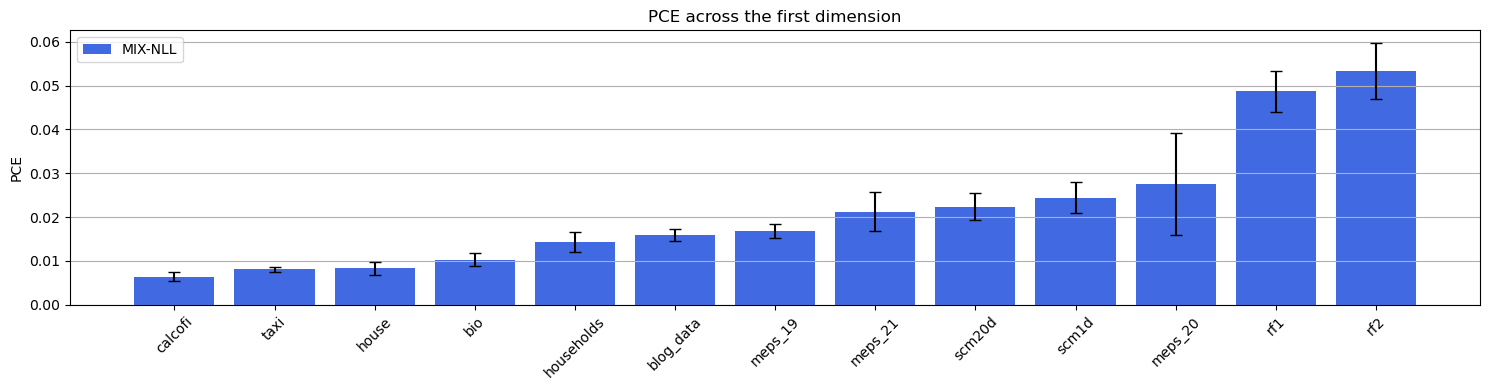

In [10]:
dataset_names = list(pce_across_datasets.keys())
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

# Step 2: Sort everything by mean PCE
sorted_indices = np.argsort(mean_pces)
sorted_names = [dataset_names[i] for i in sorted_indices]
sorted_means = [mean_pces[i] for i in sorted_indices]
sorted_stderr = [stderr_pces[i] for i in sorted_indices]

# Step 3: Plot
x = np.arange(len(sorted_names))

plt.figure(figsize=(15, 4))
plt.bar(x, sorted_means, yerr=sorted_stderr, capsize=4, color='royalblue', label='MIX-NLL')
plt.xticks(x, sorted_names, rotation=45)
plt.ylabel("PCE")
plt.title("PCE across the first dimension")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

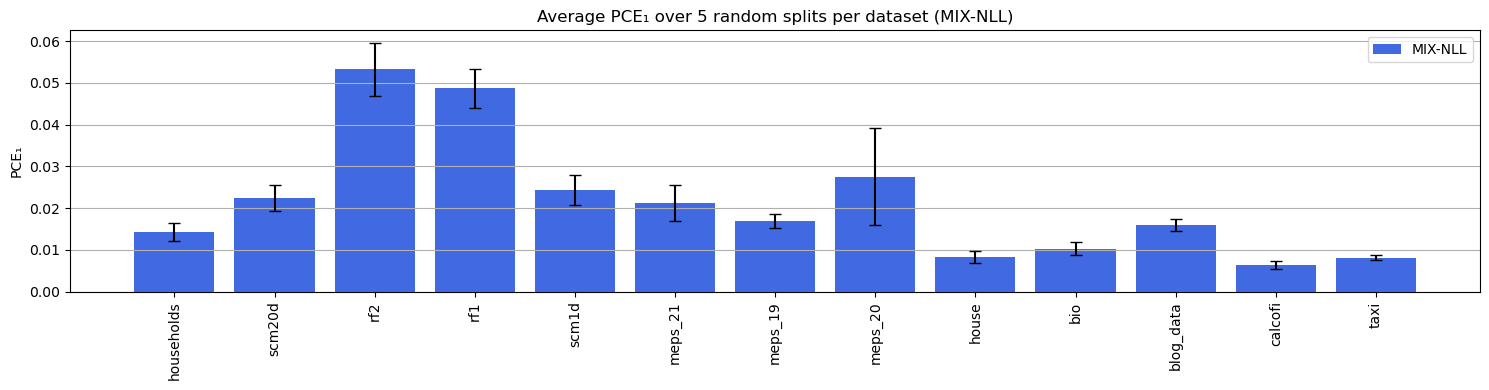

In [ ]:
# Sort dataset names alphabetically (or however you prefer)
dataset_names = pce_across_datasets.keys()

# Compute mean and standard error
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

x = np.arange(len(dataset_names))

plt.figure(figsize=(15, 4))
plt.bar(x, mean_pces, yerr=stderr_pces, capsize=4, color='royalblue', label='MIX-NLL')
# plt.axhline(y=1/12, color='orange', linestyle='--', label='Perfect Calibration (PCE = 1/12)')
plt.xticks(x, dataset_names, rotation=90)
plt.ylabel("PCE")
plt.title("Average PCE over 5 random splits per dataset (MIX-NLL)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()